# GNN Spatial Gaz (GFPP) — Prédiction 1h

Prédit `g` (injections des **4 wells**) sur **l'heure suivante**  
à partir des **72 heures d'historique** et de la **structure spatiale du réseau de gaz**.

- **Modèle** : encodeur MLP → message passing GINEConv → décodeur MLP  
- **28 nœuds**, **4 wells** (indices 0, 4, 16, 17)  
- **Fenêtres** : 72 h d'entrée, 1 h de cible, glissement de 24 h en 24 h

In [1]:
# ============================================================
# Cellule 1 - Installation / vérification de PyTorch Geometric
# ============================================================
import sys
import subprocess
import pkgutil

def ensure_package(pkg_name: str, pip_name: str | None = None):
    if pkgutil.find_loader(pkg_name) is None:
        name = pip_name or pkg_name
        print(f"Installation de {name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", name,
                               "--quiet", "--no-warn-script-location"])
        print(f"{name} installé.")
    else:
        print(f"{pkg_name} déjà disponible.")

ensure_package("torch_geometric", "torch-geometric")

import torch_geometric
print("torch_geometric version:", torch_geometric.__version__)


torch_geometric déjà disponible.


C:\Users\yoans\anaconda3\envs\torch118\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch_geometric version: 2.7.0


In [70]:
# ============================================================
# Cellule 2 - Hyperparamètres / constantes / chemins
# ============================================================
from pathlib import Path

CONFIG = {
    # ── chemins ───────────────────────────────────────────────────
    "BASE_DIR"         : Path("."),
    "PATH_NETWORK"     : Path("Gas Network Data.xlsx"),
    "PATH_CONS_DISTRIB": Path("./input/Gas Cons Distrib.xlsx"),
    "PATH_CONS_EXPORT" : Path("./input/Gas Cons Export.xlsx"),
    "PATH_CONS_IND"    : Path("./input/Gas Cons Ind.xlsx"),
    "PATH_DECISION"    : Path("./output/Decision_variablesRU.xlsx"),

    # ── structure problème ────────────────────────────────────────
    "MONTHS"   : [f"{m:02d}" for m in range(1, 13)],
    "NUM_NODES": 28,
    "WELL_IDX" : [0, 4, 16, 17],

    # ── fenêtres temporelles ──────────────────────────────────────
    # HORIZON = 1 heure  |  STRIDE = 24 h (glissement journalier)
    "HIST_HOURS"    : 72,
    "HORIZON_HOURS" : 1,
    "STRIDE_HOURS"  : 24,

    # ── split temporel ────────────────────────────────────────────
    "TRAIN_END": "2024-10-01 00:00:00",
    "VAL_END"  : "2024-11-01 00:00:00",

    # ── features dynamiques nodales ───────────────────────────────
    "USE_PR_HISTORY"             : False,
    "USE_RES_DEMAND_HISTORY"     : True,
    "USE_IND_DEMAND_HISTORY"     : True,
    "USE_EXP_DEMAND_HISTORY"     : False,
    "USE_GFPP_GAS_LOAD_HISTORY"  : True,
    "USE_G_HISTORY"              : False,
    "USE_RAW_P_HISTORY_ON_GAS_NODES": False,

    # ── features statiques nodales ────────────────────────────────
    "USE_NODE_STATIC_IS_WELL"           : True,
    "USE_NODE_STATIC_SHARES"            : True,
    "USE_NODE_STATIC_PRESSURE_BOUNDS"   : True,
    "USE_NODE_STATIC_DEGREE"            : True,
    "USE_NODE_STATIC_IS_GFPP_LOAD_NODE" : True,
    "USE_NODE_STATIC_GFPP_COUNT"        : True,

    # ── features statiques d'arête ────────────────────────────────
    "EDGE_STATIC_COLUMNS": [
        "Natural gas flow constant [MNm3/(bar*h)2]",
        "Compressor factor",
        "High Linepack",
        "Initial linepack [MNm3]",
        "Linepack constant [MNm3/bar]",
        "Estimated lenght [km]",
    ],
    "USE_BIDIRECTIONAL_EDGES": True,

    # ── paramètres GFPP ───────────────────────────────────────────
    "GFPP_P_TO_MW_MULTIPLIER"          : 100.0,
    "GFPP_GAS_ENERGY_CONTENT_MWH_PER_MNM3": 11000.0,
    "GFPP_DEFAULT_EFFICIENCY"          : 0.55,
    "GFPP_EFFICIENCY_BY_GENERATOR"     : {},
    "GFPP_USE_OPTIONAL_EFFICIENCY_COLUMN": False,
    "GFPP_OPTIONAL_EFFICIENCY_COLUMN_NAME": "Efficiency",

    # ── modèle ────────────────────────────────────────────────────
    "MODEL_TYPE"          : "gine",
    "HIDDEN_DIM"          : 128,
    "ENCODER_HIDDEN_DIMS" : [256, 128],
    "DECODER_HIDDEN_DIMS" : [256, 128],
    "NUM_MP_LAYERS"       : 4,
    "DROPOUT"             : 0.05,
    "USE_BATCHNORM"       : True,
    "RESIDUAL"            : False,

    # ── entraînement ──────────────────────────────────────────────
    "SEED"                    : 42,
    "DEVICE"                  : "cpu",
    "EPOCHS"                  : 100,
    "BATCH_SIZE"              : 24,
    "LR"                      : 5e-4,
    "WEIGHT_DECAY"            : 1e-4,
    "GRAD_CLIP_NORM"          : 2.0,
    "EARLY_STOPPING_PATIENCE" : 30,
    "SCHEDULER_FACTOR"        : 0.6,
    "SCHEDULER_PATIENCE"      : 5,
    "SCHEDULER_MIN_LR"        : 1e-6,

    # ── divers ────────────────────────────────────────────────────
    "PERSISTENCE_MODE" : "same_hour_yesterday",   # valeur 24h avant la cible
    "SAVE_MODEL_STATE" : False,
    "MODEL_STATE_PATH" : Path("spatial_gas_gnn_1h.pt"),
}

PATHS = {
    "network"     : CONFIG["BASE_DIR"] / CONFIG["PATH_NETWORK"],
    "cons_distrib": CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_DISTRIB"],
    "cons_export" : CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_EXPORT"],
    "cons_ind"    : CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_IND"],
    "decision"    : CONFIG["BASE_DIR"] / CONFIG["PATH_DECISION"],
}

print("Fichiers attendus :")
for k, v in PATHS.items():
    print(f"  {k}: {v.resolve()} | exists={v.exists()}")
for p in PATHS.values():
    assert p.exists(), f"Fichier introuvable: {p}"
print("\nCONFIG OK.")


Fichiers attendus :
  network: C:\Users\yoans\TFE - GAZ\Gas Network Data.xlsx | exists=True
  cons_distrib: C:\Users\yoans\TFE - GAZ\input\Gas Cons Distrib.xlsx | exists=True
  cons_export: C:\Users\yoans\TFE - GAZ\input\Gas Cons Export.xlsx | exists=True
  cons_ind: C:\Users\yoans\TFE - GAZ\input\Gas Cons Ind.xlsx | exists=True
  decision: C:\Users\yoans\TFE - GAZ\output\Decision_variablesRU.xlsx | exists=True

CONFIG OK.


In [71]:
# ============================================================
# Cellule 3 - Imports, seed, utilitaires de base
# ============================================================
import copy
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, NNConv

warnings.filterwarnings("ignore")

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])

DEVICE = torch.device(
    "cuda" if (CONFIG["DEVICE"] == "cuda" and torch.cuda.is_available()) else "cpu"
)
print("DEVICE =", DEVICE)

def pretty_shape(name, x):
    if isinstance(x, (np.ndarray, torch.Tensor, pd.DataFrame, pd.Series)):
        print(f"{name}: shape={getattr(x, 'shape', None)}")
    else:
        print(f"{name}: type={type(x)}")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


DEVICE = cpu


In [72]:
# ============================================================
# Cellule 4 - Lecture des données statiques du réseau de gaz
# ============================================================
nodes_df      = pd.read_excel(PATHS["network"], sheet_name="Nodes")
pipes_df      = pd.read_excel(PATHS["network"], sheet_name="Pipelines")
well_df       = pd.read_excel(PATHS["network"], sheet_name="Well")
gaswell_map_df= pd.read_excel(PATHS["network"], sheet_name="GasWellMap")
gfpp_map_df   = pd.read_excel(PATHS["network"], sheet_name="GFPPMap")

num_nodes = CONFIG["NUM_NODES"]
well_idx  = CONFIG["WELL_IDX"]

pretty_shape("nodes_df",       nodes_df)
pretty_shape("pipes_df",       pipes_df)
pretty_shape("well_df",        well_df)
pretty_shape("gaswell_map_df", gaswell_map_df)
pretty_shape("gfpp_map_df",    gfpp_map_df)

assert len(nodes_df) == num_nodes
print("Données statiques réseau gaz chargées.")


nodes_df: shape=(28, 6)
pipes_df: shape=(33, 10)
well_df: shape=(4, 10)
gaswell_map_df: shape=(28, 4)
gfpp_map_df: shape=(28, 24)
Données statiques réseau gaz chargées.


In [73]:
# ============================================================
# Cellule 5 - Mapping GFPP + consommation gaz GFPP nodale
# ============================================================
gfpp_map       = gfpp_map_df.to_numpy(dtype=float)     # [num_nodes, num_generators]
gen_cols       = list(gfpp_map_df.columns)
num_generators = len(gen_cols)

assert gfpp_map.shape == (num_nodes, num_generators)

# Générateurs GFPP connectés (colonne non nulle)
connected_generator_idx = [
    j for j in range(num_generators)
    if np.any(gfpp_map[:, j] > 0.5)
]
print(f"Nb générateurs GFPP connectés : {len(connected_generator_idx)}")
print(f"Indices générateurs p (0-based): {connected_generator_idx}")

eff_by_gen = np.full(num_generators, CONFIG["GFPP_DEFAULT_EFFICIENCY"], dtype=float)
for g_idx, eff_val in CONFIG["GFPP_EFFICIENCY_BY_GENERATOR"].items():
    eff_by_gen[g_idx] = eff_val

# Nœuds connectés à au moins 1 GFPP
is_gfpp_load_node = (gfpp_map.sum(axis=1) > 0).astype(float)
gfpp_count_per_node = (gfpp_map > 0.5).sum(axis=1).astype(float)

print(f"Nœuds avec GFPP (0-based): {np.where(is_gfpp_load_node > 0)[0].tolist()}")


Nb générateurs GFPP connectés : 22
Indices générateurs p (0-based): [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23]
Nœuds avec GFPP (0-based): [1, 2, 5, 7, 8, 10, 12, 18, 22, 23, 26]


In [74]:
# ============================================================
# Cellule 6 - Helpers de lecture des séries mensuelles 2024
# ============================================================
def read_simple_monthly_series(path: Path, months, value_col: str) -> pd.DataFrame:
    parts = []
    for m in months:
        sheet = f"{m}-2024"
        df = pd.read_excel(path, sheet_name=sheet)
        df = df[["Date Time", value_col]].rename(columns={"Date Time": "datetime"})
        df["datetime"] = pd.to_datetime(df["datetime"])
        parts.append(df)
    return pd.concat(parts, ignore_index=True).sort_values("datetime").reset_index(drop=True)

def read_decision_p_gas(months, decision_path: Path):
    """Retourne p_full_gas [T, N_gen_elec] et ts_p [T]."""
    all_arrays = []
    for m in months:
        sheet = f"p-{m}-2024"
        df = pd.read_excel(decision_path, sheet_name=sheet, header=0, index_col=0)
        all_arrays.append(df.to_numpy(dtype=float))
    p_full = np.concatenate(all_arrays, axis=0)
    ts_p   = pd.date_range("2024-01-01", periods=len(p_full), freq="h")
    return p_full, ts_p

def read_decision_g(months, decision_path: Path):
    """Retourne g_full [T, N_wells] et ts_g [T]."""
    all_arrays = []
    for m in months:
        sheet = f"g-{m}-2024"
        df = pd.read_excel(decision_path, sheet_name=sheet, header=0, index_col=0)
        all_arrays.append(df.to_numpy(dtype=float))
    g_full = np.concatenate(all_arrays, axis=0)
    ts_g   = pd.date_range("2024-01-01", periods=len(g_full), freq="h")
    return g_full, ts_g


In [75]:
# ============================================================
# Cellule 7 - Lecture et concaténation mensuelle des séries 2024
# ============================================================
MONTHS = CONFIG["MONTHS"]

cons_distrib_df = read_simple_monthly_series(PATHS["cons_distrib"], MONTHS, "Physical Flow (MNm3)")
cons_ind_df     = read_simple_monthly_series(PATHS["cons_ind"],     MONTHS, "Physical Flow (MNm3)")
cons_export_df  = read_simple_monthly_series(PATHS["cons_export"],  MONTHS, "Physical Flow (MNm3)")

p_full_gas, ts_p_gas = read_decision_p_gas(MONTHS, PATHS["decision"])
g_full,     ts_g     = read_decision_g(MONTHS, PATHS["decision"])

T = len(ts_g)
assert len(ts_g) == len(ts_p_gas) == len(cons_distrib_df) == len(cons_ind_df) == len(cons_export_df)

print("Plage temporelle :", ts_g.min(), "->", ts_g.max())
print("Nombre d'heures  :", T)
pretty_shape("g_full [T, N_wells]", g_full)
pretty_shape("p_full_gas [T, N_gen]", p_full_gas)


Plage temporelle : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
Nombre d'heures  : 8784
g_full [T, N_wells]: shape=(8784, 4)
p_full_gas [T, N_gen]: shape=(8784, 24)


In [76]:
# ============================================================
# Cellule 8 - Consommation gaz GFPP nodale [T, num_nodes]
# ============================================================
# Conversion MW électrique → MNm3 gaz
# gaz_node[t, i] = sum_j( gfpp_map[i,j] * p[t,j] * MW_mult / (energy_content * eff_j) )

p_in_MW = p_full_gas * CONFIG["GFPP_P_TO_MW_MULTIPLIER"]          # [T, N_gen]
energy_content = CONFIG["GFPP_GAS_ENERGY_CONTENT_MWH_PER_MNM3"]

gfpp_gas_nodal = np.zeros((T, num_nodes), dtype=float)
for g_idx in connected_generator_idx:
    node_of_gen = np.where(gfpp_map[:, g_idx] > 0.5)[0]
    if len(node_of_gen) == 0:
        continue
    node_idx = node_of_gen[0]
    eff = eff_by_gen[g_idx]
    gfpp_gas_nodal[:, node_idx] += p_in_MW[:, g_idx] / (energy_content * eff)

pretty_shape("gfpp_gas_nodal [T, num_nodes]", gfpp_gas_nodal)
print("Max consommation GFPP par nœud (MNm3/h):", gfpp_gas_nodal.max(axis=0).max())


gfpp_gas_nodal [T, num_nodes]: shape=(8784, 28)
Max consommation GFPP par nœud (MNm3/h): 0.20528925619834706


In [77]:
# ============================================================
# Cellule 9 - Construction du tenseur dynamique nodal [T, N, F_dyn]
# ============================================================
res_share = nodes_df["Res_Load_share_%"].to_numpy(dtype=float)
ind_share = nodes_df["Ind_Load_share_%"].to_numpy(dtype=float)
exp_share = nodes_df["Exp_Load_share_%"].to_numpy(dtype=float)

cons_res = cons_distrib_df["Physical Flow (MNm3)"].to_numpy(dtype=float)
cons_ind = cons_ind_df["Physical Flow (MNm3)"].to_numpy(dtype=float)
cons_exp = cons_export_df["Physical Flow (MNm3)"].to_numpy(dtype=float)

res_demand_nodal = cons_res[:, None] * res_share[None, :]
ind_demand_nodal = cons_ind[:, None] * ind_share[None, :]
exp_demand_nodal = cons_exp[:, None] * exp_share[None, :]

# Wells : historique g injecté aux nœuds wells
g_history_nodal = np.zeros((T, num_nodes), dtype=float)
for i, widx in enumerate(well_idx):
    g_history_nodal[:, widx] = g_full[:, i]

dyn_feature_dict = {}
if CONFIG["USE_RES_DEMAND_HISTORY"]:
    dyn_feature_dict["res_demand_nodal"]  = res_demand_nodal
if CONFIG["USE_IND_DEMAND_HISTORY"]:
    dyn_feature_dict["ind_demand_nodal"]  = ind_demand_nodal
if CONFIG["USE_EXP_DEMAND_HISTORY"]:
    dyn_feature_dict["exp_demand_nodal"]  = exp_demand_nodal
if CONFIG["USE_GFPP_GAS_LOAD_HISTORY"]:
    dyn_feature_dict["gfpp_gas_nodal"]    = gfpp_gas_nodal
if CONFIG["USE_G_HISTORY"]:
    dyn_feature_dict["g_history_nodal"]   = g_history_nodal

dyn_feature_names = list(dyn_feature_dict.keys())
assert len(dyn_feature_names) > 0

dyn_tensor = np.stack([dyn_feature_dict[k] for k in dyn_feature_names], axis=-1)
print("Features dynamiques:", dyn_feature_names)
pretty_shape("dyn_tensor [T, N, F_dyn]", dyn_tensor)


Features dynamiques: ['res_demand_nodal', 'ind_demand_nodal', 'gfpp_gas_nodal']
dyn_tensor [T, N, F_dyn]: shape=(8784, 28, 3)


In [78]:
# ============================================================
# Cellule 10 - Features statiques nodales [N, F_static]
# Version robuste pour Gas Network Data.xlsx
# ============================================================
degrees = np.zeros(num_nodes, dtype=float)
for _, row in pipes_df.iterrows():
    u = int(row["From node"]) - 1
    v = int(row["To node"])   - 1
    degrees[u] += 1
    degrees[v] += 1

node_static_parts = []
node_static_names = []

if CONFIG["USE_NODE_STATIC_IS_WELL"]:
    is_well = np.isin(np.arange(num_nodes), well_idx).astype(float)
    node_static_parts.append(is_well[:, None])
    node_static_names.append("is_well")

if CONFIG["USE_NODE_STATIC_SHARES"]:
    node_static_parts.extend([
        res_share[:, None],
        ind_share[:, None],
        exp_share[:, None],
    ])
    node_static_names.extend(["res_share", "ind_share", "exp_share"])

if CONFIG["USE_NODE_STATIC_PRESSURE_BOUNDS"]:
    # Compatible avec plusieurs noms possibles
    pmin_candidates = ["Pr_min [bar]", "Pmin (bar)", "Pmin [bar]", "Pr_min (bar)"]
    pmax_candidates = ["Pr_max [bar]", "Pmax (bar)", "Pmax [bar]", "Pr_max (bar)"]

    pmin_col = next((c for c in pmin_candidates if c in nodes_df.columns), None)
    pmax_col = next((c for c in pmax_candidates if c in nodes_df.columns), None)

    if pmin_col is None or pmax_col is None:
        raise KeyError(
            f"Colonnes de pression introuvables.\n"
            f"Colonnes disponibles : {nodes_df.columns.tolist()}"
        )

    pmin = nodes_df[pmin_col].to_numpy(dtype=float)
    pmax = nodes_df[pmax_col].to_numpy(dtype=float)

    node_static_parts.extend([pmin[:, None], pmax[:, None]])
    node_static_names.extend(["pmin_bar", "pmax_bar"])

if CONFIG["USE_NODE_STATIC_DEGREE"]:
    node_static_parts.append(degrees[:, None])
    node_static_names.append("degree")

if CONFIG["USE_NODE_STATIC_IS_GFPP_LOAD_NODE"]:
    node_static_parts.append(is_gfpp_load_node[:, None])
    node_static_names.append("is_gfpp_load_node")

if CONFIG["USE_NODE_STATIC_GFPP_COUNT"]:
    node_static_parts.append(gfpp_count_per_node[:, None])
    node_static_names.append("gfpp_count")

node_static = (
    np.concatenate(node_static_parts, axis=1).astype(np.float32)
    if node_static_parts
    else np.zeros((num_nodes, 0), dtype=np.float32)
)

print("node_static_names =", node_static_names)
pretty_shape("node_static [N, F_static]", node_static)

node_static_names = ['is_well', 'res_share', 'ind_share', 'exp_share', 'pmin_bar', 'pmax_bar', 'degree', 'is_gfpp_load_node', 'gfpp_count']
node_static [N, F_static]: shape=(28, 9)


In [79]:
# ============================================================
# Cellule 11 - Edge index + features d'arête statiques
# Version robuste
# ============================================================
edge_static_cols = CONFIG["EDGE_STATIC_COLUMNS"]
for col in edge_static_cols:
    assert col in pipes_df.columns, f"Colonne arête introuvable: {col}"

edge_static_base = (
    pipes_df[edge_static_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .to_numpy(dtype=float)
)

edge_pairs = []
edge_attrs = []

for i, row in pipes_df.iterrows():
    u = int(row["From node"]) - 1
    v = int(row["To node"])   - 1
    ea = edge_static_base[i]

    edge_pairs.append((u, v))
    edge_attrs.append(ea)

    if CONFIG["USE_BIDIRECTIONAL_EDGES"]:
        edge_pairs.append((v, u))
        edge_attrs.append(ea.copy())

edge_index = torch.tensor(np.array(edge_pairs, dtype=np.int64).T, dtype=torch.long)
edge_attr_raw = np.array(edge_attrs, dtype=np.float32)

assert edge_index.shape[0] == 2
assert edge_index.max() < num_nodes

print("edge_static_cols =", edge_static_cols)
print("Nb arêtes        =", edge_index.shape[1])
pretty_shape("edge_attr_raw [E, F]", edge_attr_raw)

edge_static_cols = ['Natural gas flow constant [MNm3/(bar*h)2]', 'Compressor factor', 'High Linepack', 'Initial linepack [MNm3]', 'Linepack constant [MNm3/bar]', 'Estimated lenght [km]']
Nb arêtes        = 66
edge_attr_raw [E, F]: shape=(66, 6)


In [80]:
# ============================================================
# Cellule 12 - Normalisation + génération des indices de fenêtres
# ============================================================
TRAIN_END = pd.Timestamp(CONFIG["TRAIN_END"])
VAL_END   = pd.Timestamp(CONFIG["VAL_END"])

HIST = int(CONFIG["HIST_HOURS"])       # 72
HOR  = int(CONFIG["HORIZON_HOURS"])    # 1
STR  = int(CONFIG["STRIDE_HOURS"])     # 24

N_WELLS = len(well_idx)

ts_g = pd.to_datetime(ts_g)

# ── Masques horaires ──────────────────────────────────────
hour_train_mask = ts_g < TRAIN_END
hour_val_mask   = (ts_g >= TRAIN_END) & (ts_g < VAL_END)
hour_test_mask  = ts_g >= VAL_END

print("Heures train/val/test :",
      int(hour_train_mask.sum()), "/",
      int(hour_val_mask.sum()), "/",
      int(hour_test_mask.sum()))

# ── Scalers (fit sur train uniquement) ───────────────────
_Tdyn, _N, _F = dyn_tensor.shape

dyn_scaler = StandardScaler()
dyn_scaler.fit(dyn_tensor[hour_train_mask].reshape(-1, _F))
dyn_tensor_scaled = dyn_scaler.transform(
    dyn_tensor.reshape(-1, _F)
).reshape(_Tdyn, _N, _F).astype(np.float32)

if node_static.shape[1] > 0:
    node_static_scaler = StandardScaler()
    node_static_scaler.fit(node_static)
    node_static_scaled = node_static_scaler.transform(node_static).astype(np.float32)
else:
    node_static_scaler = None
    node_static_scaled = node_static.copy().astype(np.float32)

if edge_attr_raw.shape[1] > 0:
    edge_scaler = StandardScaler()
    edge_scaler.fit(edge_attr_raw)
    edge_attr_scaled = edge_scaler.transform(edge_attr_raw).astype(np.float32)
else:
    edge_scaler = None
    edge_attr_scaled = edge_attr_raw.copy().astype(np.float32)

# Scaler cible global (1 seul scaler pour tous les wells)
target_scaler = StandardScaler()
target_scaler.fit(g_full[hour_train_mask].reshape(-1, 1))
g_full_scaled = target_scaler.transform(
    g_full.reshape(-1, 1)
).reshape(g_full.shape).astype(np.float32)

print("target_scaler mean/scale :", target_scaler.mean_, target_scaler.scale_)

# ── Indices de fenêtres glissantes ────────────────────────
T = len(ts_g)
all_start_indices  = np.arange(0, T - HIST - HOR + 1, STR, dtype=int)
target_start_times = ts_g[all_start_indices + HIST]

train_window_mask = target_start_times < TRAIN_END
val_window_mask   = (target_start_times >= TRAIN_END) & (target_start_times < VAL_END)
test_window_mask  = target_start_times >= VAL_END

print(f"\nFenêtres : {len(all_start_indices)} total | "
      f"train={int(train_window_mask.sum())} | "
      f"val={int(val_window_mask.sum())} | "
      f"test={int(test_window_mask.sum())}")

assert train_window_mask.sum() > 0
assert val_window_mask.sum() > 0
assert test_window_mask.sum() > 0

Heures train/val/test : 6576 / 744 / 1464
target_scaler mean/scale : [1.21370289] [0.84398355]

Fenêtres : 363 total | train=271 | val=31 | test=61


In [81]:
# ============================================================
# Cellule 13 - Construction d'une fenêtre glissante
# Entrée  : 72h d'historique → [N, 72*F_dyn + F_static]
# Cible   : injection des 4 wells sur 1h → [4, 1]
# ============================================================
def build_single_window(start_idx: int):
    start_idx = int(start_idx)

    hist_slice   = slice(start_idx,        start_idx + HIST)
    target_slice = slice(start_idx + HIST, start_idx + HIST + HOR)

    # [HIST, N, F_dyn] → [N, HIST, F_dyn] → [N, HIST*F_dyn]
    hist_dyn = dyn_tensor_scaled[hist_slice]
    hist_dyn = np.transpose(hist_dyn, (1, 0, 2)).reshape(num_nodes, -1)

    x = np.concatenate([hist_dyn, node_static_scaled], axis=1)

    # y : [N_WELLS, HOR]
    y      = g_full_scaled[target_slice].T
    y_real = g_full[target_slice].T

    return {
        "x"               : x.astype(np.float32),
        "y"               : y.astype(np.float32),
        "y_real"          : y_real.astype(np.float32),
        "start_idx"       : np.int64(start_idx),
        "target_start_idx": np.int64(start_idx + HIST),
        "target_end_idx"  : np.int64(start_idx + HIST + HOR - 1),
    }

expected_x_dim = HIST * dyn_tensor.shape[-1] + node_static_scaled.shape[1]

# Vérifications
sample0 = build_single_window(int(all_start_indices[0]))
assert sample0["x"].shape == (num_nodes, expected_x_dim)
assert sample0["y"].shape == (N_WELLS, HOR), f"Attendu ({N_WELLS},{HOR}), got {sample0['y'].shape}"

for idx in [all_start_indices[0], all_start_indices[len(all_start_indices)//2], all_start_indices[-1]]:
    s   = build_single_window(int(idx))
    ts0 = int(s["target_start_idx"])
    ts1 = int(s["target_end_idx"])
    assert np.allclose(g_full[ts0:ts1+1].T, s["y_real"]), "Alignement KO"

print(f"expected_x_dim = {expected_x_dim}")
print(f"y.shape attendu = ({N_WELLS}, {HOR})")
print("Alignement OK.")

expected_x_dim = 225
y.shape attendu = (4, 1)
Alignement OK.


In [82]:
# ============================================================
# Cellule 14 - Dataset PyG + DataLoaders
# ============================================================
class GasSpatialWindowDataset(torch.utils.data.Dataset):
    def __init__(self, start_indices):
        self.start_indices = np.array(start_indices, dtype=int)

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx: int):
        start_idx = int(self.start_indices[idx])
        sample = build_single_window(start_idx)

        data = Data(
            x          = torch.tensor(sample["x"], dtype=torch.float32),
            edge_index = edge_index.clone(),
            edge_attr  = torch.tensor(edge_attr_scaled, dtype=torch.float32),
            y          = torch.tensor(sample["y"], dtype=torch.float32),
            well_mask  = torch.tensor(
                np.isin(np.arange(num_nodes), well_idx),
                dtype=torch.bool
            ),
        )
        data.start_idx        = int(sample["start_idx"])
        data.target_start_idx = int(sample["target_start_idx"])
        data.target_end_idx   = int(sample["target_end_idx"])
        data.y_real           = torch.tensor(sample["y_real"], dtype=torch.float32)
        return data

train_start_idx = all_start_indices[train_window_mask]
val_start_idx   = all_start_indices[val_window_mask]
test_start_idx  = all_start_indices[test_window_mask]

train_ds = GasSpatialWindowDataset(train_start_idx)
val_ds   = GasSpatialWindowDataset(val_start_idx)
test_ds  = GasSpatialWindowDataset(test_start_idx)

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

print(f"len(train_ds)={len(train_ds)} | len(val_ds)={len(val_ds)} | len(test_ds)={len(test_ds)}")

batch = next(iter(train_loader))
assert batch.x.shape[1] == expected_x_dim
assert batch.edge_attr.shape[1] == edge_attr_scaled.shape[1]
assert batch.y.shape[-1] == HOR

print("Batch shapes OK.")
pretty_shape("batch.x", batch.x)
pretty_shape("batch.y", batch.y)

len(train_ds)=271 | len(val_ds)=31 | len(test_ds)=61
Batch shapes OK.
batch.x: shape=torch.Size([672, 225])
batch.y: shape=torch.Size([96, 1])


In [83]:
# ============================================================
# Cellule 15 - Bloc MLP utilitaire
# ============================================================
class MLP(nn.Module):
    def __init__(self, dims, dropout=0.0, use_batchnorm=False, activate_last=False):
        super().__init__()
        assert len(dims) >= 2
        self.dims         = list(dims)
        self.in_channels  = self.dims[0]
        self.out_channels = self.dims[-1]

        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            is_last = (i == len(dims) - 2)
            if not is_last or activate_last:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(dims[i + 1]))
                layers.append(nn.ReLU())
                if dropout > 0.0:
                    layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [84]:
# ============================================================
# Cellule 16 - Modèle GNN spatial (SpatialGasGNN)
# Encodeur MLP → message passing GINEConv → décodeur MLP
# Sortie : [B * N_WELLS, HOR]  avec HOR = 1
# ============================================================
class SpatialGasGNN(nn.Module):
    def __init__(
        self, in_dim, edge_dim, hidden_dim, horizon,
        model_type="gine", encoder_hidden_dims=(256, 128),
        decoder_hidden_dims=(128, 64), num_mp_layers=3,
        dropout=0.0, use_batchnorm=True, residual=True,
    ):
        super().__init__()
        self.model_type    = model_type.lower()
        self.hidden_dim    = hidden_dim
        self.horizon       = horizon
        self.num_mp_layers = num_mp_layers
        self.residual      = residual

        enc_dims = [in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(enc_dims, dropout=dropout,
                           use_batchnorm=use_batchnorm, activate_last=False)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_mp_layers):
            if self.model_type == "nnconv":
                edge_net = MLP([edge_dim, hidden_dim, hidden_dim * hidden_dim],
                               dropout=dropout, use_batchnorm=False, activate_last=False)
                conv = NNConv(hidden_dim, hidden_dim, nn=edge_net, aggr="mean")
            elif self.model_type == "gine":
                nn_mlp = MLP([hidden_dim, hidden_dim, hidden_dim],
                              dropout=dropout, use_batchnorm=False, activate_last=False)
                nn_mlp.in_channels = hidden_dim
                conv = GINEConv(nn=nn_mlp, edge_dim=edge_dim)
            else:
                raise ValueError(f"MODEL_TYPE inconnu: {model_type}")
            self.convs.append(conv)
            self.norms.append(nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity())

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(dec_dims, dropout=dropout,
                           use_batchnorm=use_batchnorm, activate_last=False)

    def forward(self, x, edge_index, edge_attr, well_mask):
        h = self.encoder(x)
        for conv, norm in zip(self.convs, self.norms):
            h_in = h
            h    = conv(h, edge_index, edge_attr)
            h    = norm(h)
            h    = F.relu(h)
            if self.residual:
                h = h + h_in
        h_wells = h[well_mask]            # [B*N_WELLS, hidden_dim]
        return self.decoder(h_wells)      # [B*N_WELLS, HOR]


# Test forward rapide
_model_tmp = SpatialGasGNN(
    in_dim=expected_x_dim, edge_dim=edge_attr_scaled.shape[1],
    hidden_dim=CONFIG["HIDDEN_DIM"], horizon=HOR,
    model_type=CONFIG["MODEL_TYPE"],
    encoder_hidden_dims=CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims=CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers=CONFIG["NUM_MP_LAYERS"],
    dropout=CONFIG["DROPOUT"], use_batchnorm=CONFIG["USE_BATCHNORM"],
    residual=CONFIG["RESIDUAL"],
).to(DEVICE)

_batch = next(iter(train_loader)).to(DEVICE)
with torch.no_grad():
    _pred = _model_tmp(_batch.x, _batch.edge_index, _batch.edge_attr, _batch.well_mask)
assert _pred.shape == _batch.y.view(-1, HOR).shape, f"Shape mismatch: {_pred.shape}"
print("Architecture OK. Sortie shape:", _pred.shape)
del _model_tmp, _batch, _pred


Architecture OK. Sortie shape: torch.Size([96, 1])


In [85]:
# ============================================================
# Cellule 17 - Loss, métriques, baseline persistance, boucle epoch
# ============================================================

def mse_loss_on_wells(pred: torch.Tensor, batch) -> torch.Tensor:
    y_true = batch.y.view_as(pred)
    return F.mse_loss(pred, y_true)

def inverse_targets(arr_scaled: np.ndarray) -> np.ndarray:
    """Inverse la normalisation cible (scaler global).
    arr_scaled peut être de n'importe quelle shape → reshape(-1,1).
    """
    arr = np.asarray(arr_scaled)
    return target_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(arr.shape)

def mae_rmse_nmae(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae    = float(np.mean(np.abs(y_pred - y_true)))
    rmse   = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    nmae   = mae / (float(np.mean(np.abs(y_true))) + 1e-12)
    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae}

def persistence_forecast_for_sample(start_idx: int) -> np.ndarray:
    """Prédiction [N_WELLS, HOR] : valeur observée 24h avant la cible."""
    assert HIST >= 24
    hist_g = g_full[start_idx : start_idx + HIST]   # [HIST, N_WELLS]
    pred   = hist_g[[-24]].T                         # [N_WELLS, 1] = [N_WELLS, HOR]
    assert pred.shape == (N_WELLS, HOR)
    return pred

def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_samples = 0.0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.well_mask)
            loss = mse_loss_on_wells(pred, batch)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if CONFIG["GRAD_CLIP_NORM"] is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["GRAD_CLIP_NORM"])
                optimizer.step()
        total_loss    += loss.item() * batch.num_graphs
        total_samples += batch.num_graphs
    return total_loss / max(total_samples, 1)


In [86]:
# ============================================================
# Cellule 18 - EarlyStopping
# ============================================================
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_loss   = np.inf
        self.best_state  = None
        self.counter     = 0
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = float(val_loss)
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


In [87]:
# ============================================================
# Cellule 19 - Initialisation modèle / optimiseur / scheduler
# Relancer si tu modifies l'architecture ou les hyperparamètres
# ============================================================
model = SpatialGasGNN(
    in_dim              = expected_x_dim,
    edge_dim            = edge_attr_scaled.shape[1],
    hidden_dim          = CONFIG["HIDDEN_DIM"],
    horizon             = HOR,
    model_type          = CONFIG["MODEL_TYPE"],
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers       = CONFIG["NUM_MP_LAYERS"],
    dropout             = CONFIG["DROPOUT"],
    use_batchnorm       = CONFIG["USE_BATCHNORM"],
    residual            = CONFIG["RESIDUAL"],
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"], min_lr=CONFIG["SCHEDULER_MIN_LR"],
)
early_stopper = EarlyStopping(patience=CONFIG["EARLY_STOPPING_PATIENCE"])
history = {"train_loss": [], "val_loss": [], "lr": []}

print(model)
print("\nModèle initialisé — HOR =", HOR, "— N_WELLS =", N_WELLS)


SpatialGasGNN(
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=225, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.05, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.05, inplace=False)
      (8): Linear(in_features=128, out_features=128, bias=True)
    )
  )
  (convs): ModuleList(
    (0-3): 4 x GINEConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.05, inplace=False)
        (3): Linear(in_features=128, out_features=128, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-3): 4 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decoder): MLP(
  

In [88]:
# ============================================================
# Cellule 20 - Boucle d'entraînement
# ============================================================
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss   = run_one_epoch(model, val_loader,   optimizer=None)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:03d} | train={train_loss:.6f} | val={val_loss:.6f} | "
        f"counter={early_stopper.counter}/{early_stopper.patience} | lr={current_lr:.2e}"
    )

    if early_stopper.step(val_loss, model):
        print(f"Early stopping à l'epoch {epoch}.")
        break

assert early_stopper.best_state is not None
model.load_state_dict(early_stopper.best_state)
print("\nMeilleur val_loss :", early_stopper.best_loss)

if CONFIG["SAVE_MODEL_STATE"]:
    torch.save(model.state_dict(), CONFIG["MODEL_STATE_PATH"])
    print("Modèle sauvegardé dans", CONFIG["MODEL_STATE_PATH"])


Epoch 001 | train=0.408260 | val=0.890144 | counter=0/30 | lr=5.00e-04
Epoch 002 | train=0.192309 | val=0.442903 | counter=0/30 | lr=5.00e-04
Epoch 003 | train=0.180252 | val=0.200329 | counter=0/30 | lr=5.00e-04
Epoch 004 | train=0.175614 | val=0.105607 | counter=0/30 | lr=5.00e-04
Epoch 005 | train=0.171156 | val=0.096299 | counter=0/30 | lr=5.00e-04
Epoch 006 | train=0.158978 | val=0.096970 | counter=0/30 | lr=5.00e-04
Epoch 007 | train=0.159183 | val=0.102372 | counter=1/30 | lr=5.00e-04
Epoch 008 | train=0.152862 | val=0.106317 | counter=2/30 | lr=5.00e-04
Epoch 009 | train=0.166035 | val=0.087068 | counter=3/30 | lr=5.00e-04
Epoch 010 | train=0.148860 | val=0.087313 | counter=0/30 | lr=5.00e-04
Epoch 011 | train=0.149654 | val=0.088555 | counter=1/30 | lr=5.00e-04
Epoch 012 | train=0.144602 | val=0.089191 | counter=2/30 | lr=5.00e-04
Epoch 013 | train=0.149224 | val=0.102183 | counter=3/30 | lr=5.00e-04
Epoch 014 | train=0.146989 | val=0.102486 | counter=4/30 | lr=5.00e-04
Epoch 

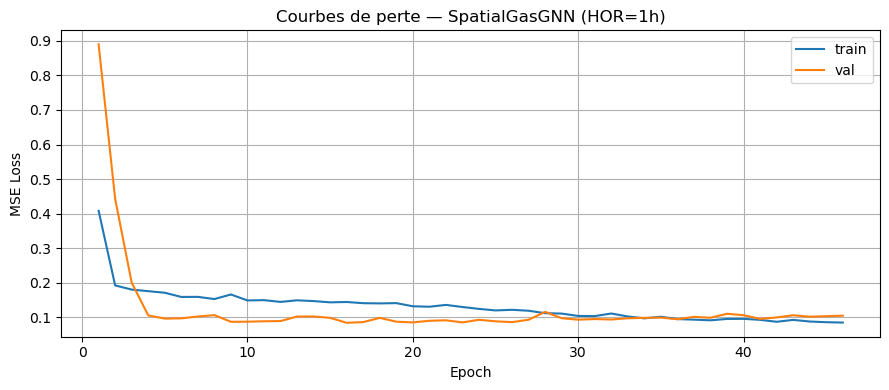

Best val_loss = 0.084159  (epoch 46)


In [89]:
# ============================================================
# Cellule 21 - Courbes d'apprentissage
# ============================================================
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_ran, history["train_loss"], label="train")
ax.plot(epochs_ran, history["val_loss"],   label="val")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Courbes de perte — SpatialGasGNN (HOR=1h)")
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()
print(f"Best val_loss = {early_stopper.best_loss:.6f}  (epoch {len(history['train_loss'])})")


In [90]:
# ============================================================
# Cellule 22 - Collecte des prédictions (train / val / test)
# ============================================================
def ensure_3d(arr: np.ndarray) -> np.ndarray:
    """[B*N_WELLS, HOR] ou [B, N_WELLS, HOR] → [B, N_WELLS, HOR]."""
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == N_WELLS and arr.shape[2] == HOR
        return arr
    assert arr.ndim == 2 and arr.shape[1] == HOR and arr.shape[0] % N_WELLS == 0
    return arr.reshape(arr.shape[0] // N_WELLS, N_WELLS, HOR)

@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    preds_scaled, trues_scaled, preds_real, trues_real, metas = [], [], [], [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        pred   = model(batch.x, batch.edge_index, batch.edge_attr, batch.well_mask)
        y_true = batch.y.view_as(pred)
        pn = pred.detach().cpu().numpy()
        tn = y_true.detach().cpu().numpy()
        preds_scaled.append(pn); trues_scaled.append(tn)
        preds_real.append(inverse_targets(pn))
        trues_real.append(inverse_targets(tn))
        if hasattr(batch, "target_start_idx"):
            metas.append(batch.target_start_idx.detach().cpu().numpy())

    return {
        "preds_scaled": np.concatenate(preds_scaled),
        "trues_scaled": np.concatenate(trues_scaled),
        "preds_real"  : np.concatenate(preds_real),
        "trues_real"  : np.concatenate(trues_real),
        "metas"       : np.concatenate(metas) if metas else np.array([]),
    }

train_out = collect_predictions(model, train_loader)
val_out   = collect_predictions(model, val_loader)
test_out  = collect_predictions(model, test_loader)

print("train preds_real.shape =", train_out["preds_real"].shape)
print("val   preds_real.shape =", val_out["preds_real"].shape)
print("test  preds_real.shape =", test_out["preds_real"].shape)


train preds_real.shape = (1084, 1)
val   preds_real.shape = (124, 1)
test  preds_real.shape = (244, 1)


In [91]:
# ============================================================
# Cellule 23 - Baseline persistance (same_hour_yesterday)
# ============================================================
def compute_persistence_split(dataset):
    preds, trues = [], []
    for start_idx in dataset.start_indices:
        start_idx = int(start_idx)
        pred = persistence_forecast_for_sample(start_idx)                # [N_WELLS, 1]
        true = g_full[start_idx + HIST : start_idx + HIST + HOR].T      # [N_WELLS, 1]
        preds.append(pred); trues.append(true)
    return np.stack(preds), np.stack(trues)   # [N, N_WELLS, HOR]

pers_train_pred, pers_train_true = compute_persistence_split(train_ds)
pers_val_pred,   pers_val_true   = compute_persistence_split(val_ds)
pers_test_pred,  pers_test_true  = compute_persistence_split(test_ds)

print("pers_test_pred.shape =", pers_test_pred.shape)


pers_test_pred.shape = (61, 4, 1)


In [92]:
# ============================================================
# Cellule 24 - Métriques finales
# ============================================================
def evaluate_model(out, split_name, model_label="SpatialGasGNN"):
    p3 = ensure_3d(out["preds_real"])   # [B, N_WELLS, 1]
    t3 = ensure_3d(out["trues_real"])
    rows = []
    m = mae_rmse_nmae(t3, p3); m.update({"split": split_name, "model": model_label, "well": "global"}); rows.append(m)
    for j, widx in enumerate(CONFIG["WELL_IDX"]):
        m = mae_rmse_nmae(t3[:, j, :], p3[:, j, :])
        m.update({"split": split_name, "model": model_label, "well": f"well_{widx}"})
        rows.append(m)
    return pd.DataFrame(rows)

def evaluate_persistence(pred, true, split_name):
    rows = []
    m = mae_rmse_nmae(true, pred); m.update({"split": split_name, "model": "Persistence", "well": "global"}); rows.append(m)
    for j, widx in enumerate(CONFIG["WELL_IDX"]):
        m = mae_rmse_nmae(true[:, j, :], pred[:, j, :])
        m.update({"split": split_name, "model": "Persistence", "well": f"well_{widx}"})
        rows.append(m)
    return pd.DataFrame(rows)

metrics_df = pd.concat([
    evaluate_model(train_out, "train"),
    evaluate_model(val_out,   "val"),
    evaluate_model(test_out,  "test"),
    evaluate_persistence(pers_train_pred, pers_train_true, "train"),
    evaluate_persistence(pers_val_pred,   pers_val_true,   "val"),
    evaluate_persistence(pers_test_pred,  pers_test_true,  "test"),
], ignore_index=True)

print("=== Résumé TEST — métriques globales ===")
display(
    metrics_df[
        (metrics_df["split"] == "test") & (metrics_df["well"] == "global")
    ][["model", "MAE", "RMSE", "NMAE"]].reset_index(drop=True)
)

print("\n=== Résumé TEST — par well (SpatialGasGNN) ===")
display(
    metrics_df[
        (metrics_df["split"] == "test") &
        (metrics_df["model"] == "SpatialGasGNN") &
        (metrics_df["well"] != "global")
    ][["well", "MAE", "RMSE", "NMAE"]].reset_index(drop=True)
)


=== Résumé TEST — métriques globales ===


,model,MAE,RMSE,NMAE
0,SpatialGasGNN,0.288284,0.357534,0.311149
1,Persistence,0.231626,0.323881,0.249997



=== Résumé TEST — par well (SpatialGasGNN) ===


,well,MAE,RMSE,NMAE
0,well_0,0.239302,0.316684,0.111736
1,well_4,0.407637,0.480985,1.060922
2,well_16,0.341571,0.380800,0.309155
3,well_17,0.164624,0.186221,2.186516


In [93]:
# ============================================================
# Cellule — TEST | métriques sur total agrégé + roughness
# Compatible notebook gaz 1h
# ============================================================
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def to_3d_targets(arr, n_targets=None, hor=None):
    """
    Convertit en [B, N_TARGETS, HOR]
    Accepte :
    - [B, N_TARGETS, HOR]
    - [B*N_TARGETS, HOR]
    - [B, N_TARGETS] si HOR=1
    """
    arr = np.asarray(arr)

    if arr.ndim == 3:
        return arr

    if arr.ndim == 2:
        if n_targets is None:
            if "N_WELLS" in globals():
                n_targets = N_WELLS
            elif "well_idx" in globals():
                n_targets = len(well_idx)
            else:
                raise ValueError("Impossible d'inférer N_WELLS.")
        if hor is None:
            if "HOR" in globals():
                hor = HOR
            elif "CONFIG" in globals():
                hor = int(CONFIG["HORIZON_HOURS"])
            else:
                hor = arr.shape[1]

        # cas [B, N_TARGETS] avec HOR=1
        if hor == 1 and arr.shape[1] == n_targets:
            return arr[:, :, None]

        # cas [B*N_TARGETS, HOR]
        if arr.shape[1] == hor and arr.shape[0] % n_targets == 0:
            B = arr.shape[0] // n_targets
            return arr.reshape(B, n_targets, hor)

    raise ValueError(f"Shape non supportée pour conversion 3D : {arr.shape}")


def mae_rmse_nmae_local(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

    denom = float(np.mean(np.abs(y_true)))
    nmae = float(mae / denom) if denom > eps else np.nan

    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae}


def roughness_1d(x):
    x = np.asarray(x).reshape(-1)
    if len(x) < 2:
        return np.nan
    return float(np.mean(np.abs(np.diff(x))))


def evaluate_aggregated_total(y_true, y_pred, model_label="SpatialGasGNN", split_name="test"):
    """
    Agrège sur les wells :
    [B, N_WELLS, HOR] -> [B, HOR]
    puis calcule les métriques et la roughness sur la série agrégée aplatie.
    """
    t3 = to_3d_targets(y_true)
    p3 = to_3d_targets(y_pred)

    # somme sur les wells
    t_agg = t3.sum(axis=1)   # [B, HOR]
    p_agg = p3.sum(axis=1)   # [B, HOR]

    # métriques sur total agrégé
    m = mae_rmse_nmae_local(t_agg, p_agg)

    # roughness sur série temporelle agrégée
    t_agg_flat = t_agg.reshape(-1)
    p_agg_flat = p_agg.reshape(-1)

    rough_true = roughness_1d(t_agg_flat)
    rough_pred = roughness_1d(p_agg_flat)
    rough_err = rough_pred - rough_true

    row = {
        "split": split_name,
        "model": model_label,
        "target": "aggregated_total",
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "NMAE": m["NMAE"],
        "rough_true": rough_true,
        "rough_pred": rough_pred,
        "rough_err": rough_err,
        "rough_err_abs": abs(rough_err),
    }

    return pd.DataFrame([row]), t_agg, p_agg


# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------
assert "test_out" in globals(), "test_out absent."
assert "trues_real" in test_out and "preds_real" in test_out, "test_out doit contenir 'trues_real' et 'preds_real'."
assert "pers_test_true" in globals(), "pers_test_true absent."
assert "pers_test_pred" in globals(), "pers_test_pred absent."

# ------------------------------------------------------------
# SpatialGasGNN
# ------------------------------------------------------------
agg_test_gnn_df, test_true_agg, test_pred_agg = evaluate_aggregated_total(
    test_out["trues_real"],
    test_out["preds_real"],
    model_label="SpatialGasGNN",
    split_name="test"
)

# ------------------------------------------------------------
# Persistence
# ------------------------------------------------------------
agg_test_pers_df, pers_true_agg, pers_pred_agg = evaluate_aggregated_total(
    pers_test_true,
    pers_test_pred,
    model_label="Persistence",
    split_name="test"
)

# ------------------------------------------------------------
# Tableau final
# ------------------------------------------------------------
agg_test_metrics_df = pd.concat(
    [agg_test_gnn_df, agg_test_pers_df],
    ignore_index=True
)

print("=== TEST — métriques sur le total agrégé (somme des wells) ===")
display(
    agg_test_metrics_df[
        ["model", "MAE", "RMSE", "NMAE", "rough_true", "rough_pred", "rough_err", "rough_err_abs"]
    ]
)

# ------------------------------------------------------------
# Infos utiles
# ------------------------------------------------------------
print("\nShapes agrégées :")
print("test_true_agg :", test_true_agg.shape)
print("test_pred_agg :", test_pred_agg.shape)
print("pers_true_agg :", pers_true_agg.shape)
print("pers_pred_agg :", pers_pred_agg.shape)

=== TEST — métriques sur le total agrégé (somme des wells) ===


,model,MAE,RMSE,NMAE,rough_true,rough_pred,rough_err,rough_err_abs
0,SpatialGasGNN,0.858551,0.956515,0.231662,0.593544,0.199751,-0.393793,0.393793
1,Persistence,0.587926,0.804617,0.158640,0.593544,0.585837,-0.007707,0.007707



Shapes agrégées :
test_true_agg : (61, 1)
test_pred_agg : (61, 1)
pers_true_agg : (61, 1)
pers_pred_agg : (61, 1)


In [94]:
# ============================================================
# Cellule — Métriques agrégées sur TEST + roughness
# Compatible avec ton notebook gaz 1h
# Calculée de la même manière que pour l'élec
# ============================================================
import numpy as np
import pandas as pd

def roughness_1d(x):
    x = np.asarray(x).reshape(-1)
    if len(x) < 2:
        return np.nan
    return float(np.mean(np.abs(np.diff(x))))

def compute_aggregated_metrics_gas(y_true, y_pred, label="SpatialGasGNN", split="test"):
    """
    y_true, y_pred attendus sous forme :
    - [B*N_WELLS, HOR]
    - ou [B, N_WELLS, HOR]

    On agrège en sommant sur les wells :
    -> série agrégée de shape [B, HOR]
    """
    t3 = ensure_3d(y_true)   # [B, N_WELLS, HOR]
    p3 = ensure_3d(y_pred)   # [B, N_WELLS, HOR]

    # Somme sur les wells
    t_agg = t3.sum(axis=1)   # [B, HOR]
    p_agg = p3.sum(axis=1)   # [B, HOR]

    # Métriques agrégées, même logique que l'élec
    m = mae_rmse_nmae(t_agg, p_agg)

    # Roughness sur la série agrégée aplatie
    rough_true = roughness_1d(t_agg.reshape(-1))
    rough_pred = roughness_1d(p_agg.reshape(-1))
    rough_err  = rough_pred - rough_true

    m.update({
        "split": split,
        "model": label,
        "well": "aggregated_total",
        "well_name": "sum_all_wells",
        "rough_true": rough_true,
        "rough_pred": rough_pred,
        "rough_err": rough_err,
        "rough_err_abs": abs(rough_err),
    })
    return pd.DataFrame([m])

# ------------------------------------------------------------
# SpatialGasGNN — TEST agrégé
# ------------------------------------------------------------
agg_gnn_test_df = compute_aggregated_metrics_gas(
    test_out["trues_real"],
    test_out["preds_real"],
    label="SpatialGasGNN",
    split="test"
)

# ------------------------------------------------------------
# Persistence — TEST agrégé
# ------------------------------------------------------------
agg_pers_test_df = compute_aggregated_metrics_gas(
    pers_test_true,
    pers_test_pred,
    label="Persistence",
    split="test"
)

# ------------------------------------------------------------
# Résumé
# ------------------------------------------------------------
agg_test_metrics_df = pd.concat(
    [agg_gnn_test_df, agg_pers_test_df],
    ignore_index=True
)

print("=== TEST — métriques agrégées (somme de tous les wells) ===")
display(
    agg_test_metrics_df[
        ["model", "MAE", "RMSE", "NMAE", "rough_true", "rough_pred", "rough_err", "rough_err_abs"]
    ]
)

# ------------------------------------------------------------
# Optionnel : séries agrégées pour analyses futures
# ------------------------------------------------------------
t3_test = ensure_3d(test_out["trues_real"])
p3_test = ensure_3d(test_out["preds_real"])

test_true_agg = t3_test.sum(axis=1)   # [B, HOR]
test_pred_agg = p3_test.sum(axis=1)   # [B, HOR]

pers_t3_test = ensure_3d(pers_test_true)
pers_p3_test = ensure_3d(pers_test_pred)

pers_true_agg = pers_t3_test.sum(axis=1)   # [B, HOR]
pers_pred_agg = pers_p3_test.sum(axis=1)   # [B, HOR]

print("Shapes agrégées :")
print("test_true_agg :", test_true_agg.shape)
print("test_pred_agg :", test_pred_agg.shape)
print("pers_true_agg :", pers_true_agg.shape)
print("pers_pred_agg :", pers_pred_agg.shape)

=== TEST — métriques agrégées (somme de tous les wells) ===


,model,MAE,RMSE,NMAE,rough_true,rough_pred,rough_err,rough_err_abs
0,SpatialGasGNN,0.858551,0.956515,0.231662,0.593544,0.199751,-0.393793,0.393793
1,Persistence,0.587926,0.804617,0.158640,0.593544,0.585837,-0.007707,0.007707


Shapes agrégées :
test_true_agg : (61, 1)
test_pred_agg : (61, 1)
pers_true_agg : (61, 1)
pers_pred_agg : (61, 1)
